In [22]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import xgboost as xgb
from sklearn.ensemble import VotingClassifier
import joblib
import gc
import re
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')  # Updated to use a valid style name
sns.set_theme()  # Updated to use the default seaborn theme
sns.set_palette('husl')

In [18]:
import pandas as pd

email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Category Modeling/final_email_category_balanced.csv')

In [19]:
email_data['Qwen2.5_Category'].value_counts()

Qwen2.5_Category
General Business Communication              55924
Finance & Transactions                      35682
Personal Communication & Purely Personal    29053
Meeting & Scheduling                        21720
IT Alerts & System Notifications            20000
Spam                                        20000
Legal & Contractual                         20000
Project Management & Strategy               20000
Internal Policies & HR Updates              20000
Name: count, dtype: int64

Loading dataset...
Initial dataset size: 242379
Cleaning data...
Final dataset size: 140023

Class distribution:
Qwen2.5_Category
General Business Communication              0.340266
Finance & Transactions                      0.201038
Personal Communication & Purely Personal    0.136749
Meeting & Scheduling                        0.135035
Legal & Contractual                         0.105547
Spam                                        0.027831
Project Management & Strategy               0.027374
IT Alerts & System Notifications            0.016704
Internal Policies & HR Updates              0.009456
Name: proportion, dtype: float64


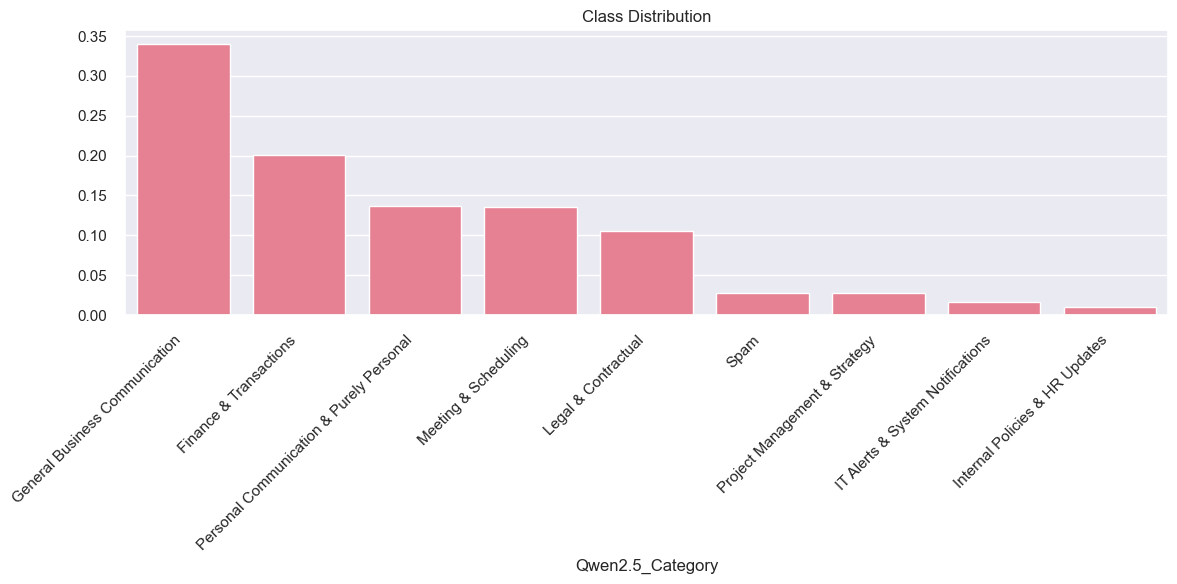

In [20]:
# Data Loading and Preprocessing
def clean_text(text):
    """Clean and preprocess text."""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = ' '.join(text.split())
    return text

def extract_email_features(subject, message):
    """Extract enhanced email-specific features."""
    subject_words = subject.split()
    message_words = message.split()
    subject_len = len(subject_words)
    message_len = len(message_words)
    
    subject_questions = subject.count('?')
    message_questions = message.count('?')
    subject_exclamations = subject.count('!')
    message_exclamations = message.count('!')
    
    subject_upper = sum(1 for c in subject if c.isupper())
    message_upper = sum(1 for c in message if c.isupper())
    subject_upper_ratio = subject_upper / (len(subject) + 1)
    message_upper_ratio = message_upper / (len(message) + 1)
    
    subject_digits = sum(1 for c in subject if c.isdigit())
    message_digits = sum(1 for c in message if c.isdigit())
    subject_digit_ratio = subject_digits / (len(subject) + 1)
    message_digit_ratio = message_digits / (len(message) + 1)
    
    has_url = int(bool(re.search(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', message)))
    has_email = int(bool(re.search(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', message)))
    
    subject_special = sum(not c.isalnum() and not c.isspace() for c in subject) / (len(subject) + 1)
    message_special = sum(not c.isalnum() and not c.isspace() for c in message) / (len(message) + 1)
    
    return np.array([
        subject_len, message_len,
        subject_questions, message_questions,
        subject_exclamations, message_exclamations,
        subject_upper_ratio, message_upper_ratio,
        subject_digit_ratio, message_digit_ratio,
        has_url, has_email,
        subject_special, message_special,
        subject_len / (message_len + 1),
        (subject_questions + message_questions) / (subject_len + message_len + 1),
        (subject_exclamations + message_exclamations) / (subject_len + message_len + 1)
    ])

# Load and preprocess data
print("Loading dataset...")
#email_data = pd.read_csv("final_email_category_balanced.csv")
print(f"Initial dataset size: {len(email_data)}")

# Clean data
print("Cleaning data...")
email_data = email_data[
    (email_data['Cleaned_Subject'].str.len() >= 3) & 
    (email_data['Cleaned_Message'].str.len() >= 10)
].drop_duplicates(subset=['Cleaned_Subject', 'Cleaned_Message']).reset_index(drop=True)
print(f"Final dataset size: {len(email_data)}")

# Print class distribution
print("\nClass distribution:")
class_dist = email_data['Qwen2.5_Category'].value_counts(normalize=True)
print(class_dist)

# Visualize class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=class_dist.index, y=class_dist.values)
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

In [11]:
email_data['Qwen2.5_Category'].value_counts()

Qwen2.5_Category
General Business Communication              47645
Finance & Transactions                      28150
Personal Communication & Purely Personal    19148
Meeting & Scheduling                        18908
Legal & Contractual                         14779
Spam                                         3897
Project Management & Strategy                3833
IT Alerts & System Notifications             2339
Internal Policies & HR Updates               1324
Name: count, dtype: int64

In [21]:
# Feature Engineering
# Clean and prepare text data
print("Preparing text features...")
email_data['cleaned_subject'] = email_data['Cleaned_Subject'].apply(clean_text)
email_data['cleaned_message'] = email_data['Cleaned_Message'].apply(clean_text)
email_data['combined_text'] = email_data['cleaned_subject'] + ' SUBJECT_END ' + email_data['cleaned_message']

# Extract numerical features
print("Extracting numerical features...")
additional_features = np.vstack([
    extract_email_features(row['Cleaned_Subject'], row['Cleaned_Message'])
    for _, row in email_data.iterrows()
])

# Scale features
print("Scaling features...")
minmax_scaler = MinMaxScaler()
additional_features_scaled = minmax_scaler.fit_transform(additional_features)

# Prepare text vectorizer
print("Preparing vectorizer...")
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=15,
    max_df=0.85,
    stop_words='english',
    sublinear_tf=True,
    norm='l2',
    use_idf=True,
    smooth_idf=True
)

# Vectorize text
print("Vectorizing text...")
X_text = vectorizer.fit_transform(email_data['combined_text'])

# Combine features
print("Combining features...")
from scipy.sparse import hstack, csr_matrix
additional_features_sparse = csr_matrix(additional_features_scaled)
X = hstack([X_text, additional_features_sparse]).tocsr()

# Prepare target
y = email_data['Qwen2.5_Category']
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Preparing text features...
Extracting numerical features...
Scaling features...
Preparing vectorizer...
Vectorizing text...
Combining features...
Training set size: 112018
Test set size: 28005


In [13]:
# Model Training and Evaluation
# Define models
models = {
    'SVM': LinearSVC(
        class_weight='balanced',
        dual=False,
        max_iter=2000,
        random_state=42,
        C=1.0
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        n_jobs=-1,
        C=1.0,
        solver='saga',
        multi_class='multinomial'
    ),
    'Naive Bayes': MultinomialNB(
        alpha=0.5,
        fit_prior=True
    ),
    'XGBoost': xgb.XGBClassifier(
        tree_method='hist',
        max_depth=7,
        learning_rate=0.05,
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        enable_categorical=False,
        use_label_encoder=False,
        objective='multi:softmax',
        num_class=len(np.unique(y_encoded)),
        verbosity=2,
        max_bin=256,
        grow_policy='lossguide',
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1
    )
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Train final model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store results
    results[name] = {
        'cv_scores': cv_scores,
        'accuracy': accuracy,
        'report': report,
        'model': model
    }
    
    print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Test accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Training SVM...
Average CV score: 0.6222 (+/- 0.0013)
Test accuracy: 0.6247

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.61      0.64      5630
           1       0.72      0.49      0.58      9529
           2       0.35      0.71      0.47       468
           3       0.15      0.55      0.23       265
           4       0.58      0.71      0.64      2956
           5       0.75      0.77      0.76      3782
           6       0.67      0.76      0.71      3830
           7       0.25      0.50      0.33       766
           8       0.57      0.79      0.66       779

    accuracy                           0.62     28005
   macro avg       0.52      0.65      0.56     28005
weighted avg       0.66      0.62      0.63     28005


Training Logistic Regression...
Average CV score: 0.5698 (+/- 0.0237)
Test accuracy: 0.5811

Classification Report:
              precision    recall  f1-score   support

           0       0.6

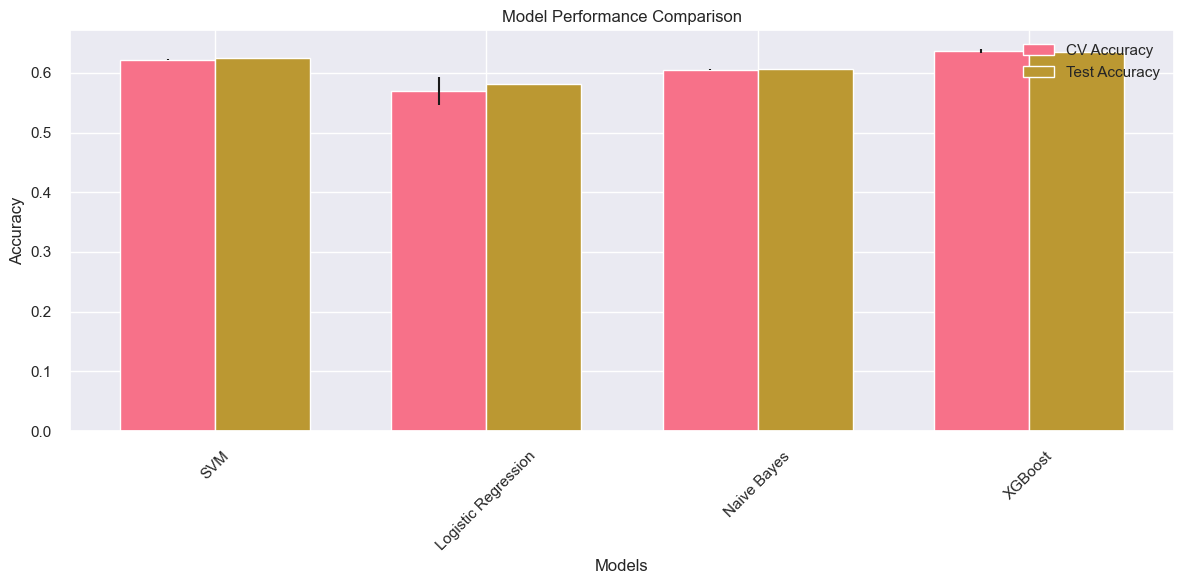

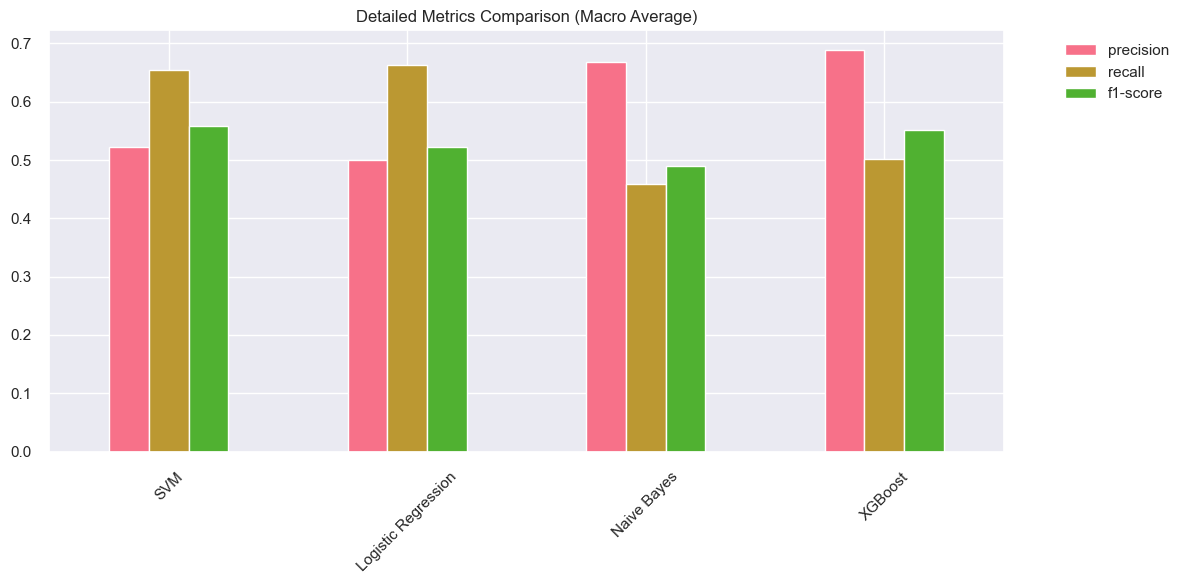


Model Performance Summary:
                 Model  CV Accuracy (Mean)  CV Accuracy (Std)  Test Accuracy  \
0                  SVM              0.6222             0.0013         0.6247   
1  Logistic Regression              0.5698             0.0237         0.5811   
2          Naive Bayes              0.6055             0.0016         0.6056   
3              XGBoost              0.6365             0.0026         0.6355   

   Macro Precision  Macro Recall  Macro F1-Score  
0           0.5229        0.6535          0.5585  
1           0.4999        0.6632          0.5227  
2           0.6679        0.4582          0.4895  
3           0.6878        0.5010          0.5512  


In [14]:
# Model Comparison and Visualization
# Compare model performance
model_names = list(results.keys())
cv_means = [results[name]['cv_scores'].mean() for name in model_names]
cv_stds = [results[name]['cv_scores'].std() for name in model_names]
test_accuracies = [results[name]['accuracy'] for name in model_names]

# Create performance comparison plot
plt.figure(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, cv_means, width, label='CV Accuracy', yerr=cv_stds, capsize=5)
plt.bar(x + width/2, test_accuracies, width, label='Test Accuracy')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Create detailed metrics comparison
metrics = ['precision', 'recall', 'f1-score']
macro_metrics = {}
for name in model_names:
    macro_metrics[name] = {
        metric: results[name]['report']['macro avg'][metric]
        for metric in metrics
    }

metrics_df = pd.DataFrame(macro_metrics).T
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Detailed Metrics Comparison (Macro Average)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print summary table
summary_df = pd.DataFrame({
    'Model': model_names,
    'CV Accuracy (Mean)': cv_means,
    'CV Accuracy (Std)': cv_stds,
    'Test Accuracy': test_accuracies,
    'Macro Precision': [results[name]['report']['macro avg']['precision'] for name in model_names],
    'Macro Recall': [results[name]['report']['macro avg']['recall'] for name in model_names],
    'Macro F1-Score': [results[name]['report']['macro avg']['f1-score'] for name in model_names]
})

print("\nModel Performance Summary:")
print(summary_df.round(4))

In [ ]:
# Save Best Model
# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']

# Save best model and related objects
model_data = {
    'model': best_model,
    'vectorizer': vectorizer,
    'scaler': minmax_scaler,
    'label_encoder': label_encoder
}

joblib.dump(model_data, 'best_email_category_model.joblib')
print(f"\nBest model ({best_model_name}) saved to 'best_email_category_model.joblib'")


Best model (XGBoost) saved to 'best_email_category_model.joblib'


# MODEL Hyperturning


In [23]:
# 1. Enhanced Feature Engineering
print("Adding enhanced features...")

# 1.1 Text Complexity Features
def extract_text_complexity(text):
    words = text.split()
    sentences = text.split('.')
    return {
        'avg_word_length': np.mean([len(word) for word in words]) if words else 0,
        'avg_sentence_length': np.mean([len(sent.split()) for sent in sentences]) if sentences else 0,
        'unique_word_ratio': len(set(words)) / len(words) if words else 0,
        'special_char_ratio': sum(1 for char in text if not char.isalnum() and not char.isspace()) / len(text) if text else 0
    }

# 1.2 Category-Specific Features
def extract_category_features(text):
    # Meeting features
    meeting_keywords = ['meeting', 'schedule', 'appointment', 'calendar', 'time', 'date']
    meeting_count = sum(1 for word in meeting_keywords if word in text.lower())
    
    # Finance features
    finance_keywords = ['payment', 'invoice', 'transaction', 'amount', 'balance']
    finance_count = sum(1 for word in finance_keywords if word in text.lower())
    
    # Legal features
    legal_keywords = ['agreement', 'contract', 'terms', 'conditions', 'legal']
    legal_count = sum(1 for word in legal_keywords if word in text.lower())
    
    # IT features
    it_keywords = ['error', 'system', 'server', 'network', 'database']
    it_count = sum(1 for word in it_keywords if word in text.lower())
    
    return {
        'meeting_keyword_count': meeting_count,
        'finance_keyword_count': finance_count,
        'legal_keyword_count': legal_count,
        'it_keyword_count': it_count
    }

# 1.3 Formatting Features
def extract_formatting_features(text):
    return {
        'caps_ratio': sum(1 for char in text if char.isupper()) / len(text) if text else 0,
        'digit_ratio': sum(1 for char in text if char.isdigit()) / len(text) if text else 0,
        'url_count': len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text)),
        'email_count': len(re.findall(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', text))
    }

# Extract enhanced features
print("Extracting enhanced features...")
enhanced_features = []
for _, row in email_data.iterrows():
    text = row['combined_text']
    features = {}
    features.update(extract_text_complexity(text))
    features.update(extract_category_features(text))
    features.update(extract_formatting_features(text))
    enhanced_features.append(features)

# Convert to DataFrame and scale
enhanced_features_df = pd.DataFrame(enhanced_features)
enhanced_features_scaled = minmax_scaler.fit_transform(enhanced_features_df)
enhanced_features_sparse = csr_matrix(enhanced_features_scaled)

# Combine with existing features
print("Combining enhanced features...")
X = hstack([X, enhanced_features_sparse]).tocsr()

Adding enhanced features...
Extracting enhanced features...
Combining enhanced features...


In [ ]:
from sklearn.model_selection import GridSearchCV

# 2. Hyperparameter Tuning for XGBoost
print("\nPerforming hyperparameter tuning for XGBoost...")

# Define parameter grid
param_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Create base model
xgb_model = xgb.XGBClassifier(
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    objective='multi:softmax',
    num_class=len(np.unique(y_encoded))
)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Get best parameters
best_params = grid_search.best_params_
print("\nBest parameters found:")
print(best_params)

# Update XGBoost model with best parameters
models['XGBoost'] = xgb.XGBClassifier(
    **best_params,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    objective='multi:softmax',
    num_class=len(np.unique(y_encoded))
)


Performing hyperparameter tuning for XGBoost...
Fitting 3 folds for each of 2187 candidates, totalling 6561 fits
